# Rescorla-Wagner Parameters Clustering with PCA

## RQ3(II): Do prompt-engineered personas reliably induce distinct RW parameter phenotypes within each model, and does a sham persona fail to induce distinct clusters (negative control)?

An unsupervised clustering analysis of the AI agents' (and Humans') underlying cognitive mechanics, using Rescorla-Wagner modeling to group them by learning rate and exploration strategies.

#### Breakdown of this Notebook:

1. Load and prepare data
2. Identify cognitive learning clusters
3. Visualise cognitive parameter structure
4. Interpret clusters
5. Test persona effects
6. Compare models
7. Benchmark against human behaviour

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

from scipy.stats import chi2_contingency

In [2]:
gemini = pd.read_csv("../data/iowa_models/gemini/gemini_rw_persona_results.csv")
deepseek = pd.read_csv("../data/iowa_models/deepseek/deepseek_rw_persona_results.csv")

# Add dataset label
gemini["dataset"] = "Gemini"
deepseek["dataset"] = "DeepSeek"

# Combine
df = pd.concat([gemini, deepseek], ignore_index=True)

print(df.shape)
df.head()

(700, 10)


,run_id,model,session_id,persona,n_trials,alpha,beta,nll,converged,dataset
0,0,gemini,1,baseline,100,0.037036,25.077058,25.343762,True,Gemini
1,1,gemini,2,baseline,100,0.927472,0.554846,87.479564,True,Gemini
2,2,gemini,3,baseline,100,0.819321,1.239510,53.298904,True,Gemini
3,3,gemini,4,baseline,100,0.223039,4.842255,20.265133,True,Gemini
4,4,gemini,5,baseline,100,0.095359,12.261882,23.288650,True,Gemini


In [3]:
print(df["dataset"].value_counts())
print(df["persona"].value_counts())

print(df[["alpha", "beta"]].describe().round(3))

dataset
Gemini      350
DeepSeek    350
Name: count, dtype: int64
persona
baseline        100
exploratory     100
disengaged      100
risk_averse     100
risk_seeking    100
sham_style      100
sham_topic      100
Name: count, dtype: int64
         alpha     beta
count  700.000  700.000
mean     0.194   12.103
std      0.298   27.075
min      0.000    0.000
25%      0.001    0.066
50%      0.044    1.169
75%      0.246    8.239
max      1.000  100.000


In [4]:
feature_cols = ["alpha", "beta"]

df = df.dropna(subset=feature_cols).copy()

X = df[feature_cols].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape used for clustering:", X_scaled.shape)

Shape used for clustering: (700, 2)


In [5]:
df[feature_cols].describe()

,alpha,beta
count,700.000000,700.000000
mean,0.193508,12.103482
std,0.297921,27.075240
min,0.000100,0.000100
25%,0.000551,0.066004
50%,0.044348,1.169210
75%,0.246456,8.238970
max,0.999900,100.000000


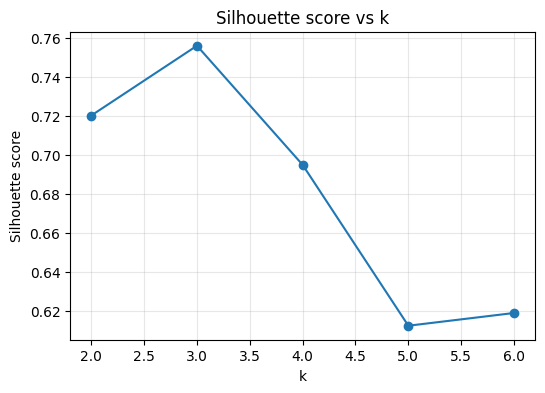

,k,silhouette
0,2,0.7204
1,3,0.7562
2,4,0.6951
3,5,0.6126
4,6,0.6192


In [6]:
ks = range(2, 7)
scores = []

for k in ks:
    labels = KMeans(n_clusters=k, random_state=42, n_init=50).fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(list(ks), scores, marker="o")
plt.title("Silhouette score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(alpha=0.3)
plt.show()

silhouette_table = pd.DataFrame({"k": list(ks), "silhouette": scores})
display(silhouette_table.round(4))

In [7]:
k_shared = ks[scores.index(max(scores))]
print("Chosen k:", k_shared)

Chosen k: 3


## Robustness check across 3 clustering methods

We compare K-means, Gaussian Mixture Models, and Agglomerative clustering using silhouette and pairwise agreement (Adjusted Rand Index).

In [8]:
# K-means
kmeans = KMeans(n_clusters=k_shared, random_state=42, n_init=50)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# GMM
df["gmm_cluster"] = GaussianMixture(
    n_components=k_shared, random_state=42
).fit_predict(X_scaled)

# Agglomerative
df["agg_cluster"] = AgglomerativeClustering(
    n_clusters=k_shared, linkage="ward"
).fit_predict(X_scaled)

In [9]:
metrics_df = pd.DataFrame({
    "silhouette": [
        silhouette_score(X_scaled, df["kmeans_cluster"]),
        silhouette_score(X_scaled, df["gmm_cluster"]),
        silhouette_score(X_scaled, df["agg_cluster"])
    ],
    "method": ["K-means", "GMM", "Agglomerative"]
}).set_index("method")

display(metrics_df.round(4))

print("ARI: K-means vs GMM =", round(adjusted_rand_score(df["kmeans_cluster"], df["gmm_cluster"]), 4))
print("ARI: K-means vs Agg =", round(adjusted_rand_score(df["kmeans_cluster"], df["agg_cluster"]), 4))
print("ARI: GMM vs Agg     =", round(adjusted_rand_score(df["gmm_cluster"], df["agg_cluster"]), 4))

,silhouette
method,
K-means,0.7562
GMM,0.1504
Agglomerative,0.6842


ARI: K-means vs GMM = 0.1908
ARI: K-means vs Agg = 0.7209
ARI: GMM vs Agg     = 0.2147


In [10]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

df["pca_x"] = coords[:, 0]
df["pca_y"] = coords[:, 1]

print("Explained variance:", round(pca.explained_variance_ratio_.sum(), 3))

Explained variance: 1.0


**Note:** PCA is not used here to reduce dimensionality (features are already 2D). Instead, it rotates the axes to align with the maximum variance, creating a clearer visual spread (the V-shape) and turning raw alpha/beta into interpretable metrics.

## Creating consistent cluster labels

In [11]:
def make_cluster_mapping(df, cluster_col, alpha_col="alpha", beta_col="beta"):
    centers = df.groupby(cluster_col)[[alpha_col, beta_col]].mean()

    mapping = {}

    for cluster, row in centers.iterrows():
        alpha = row[alpha_col]
        beta = row[beta_col]

        # Rule-based mapping
        if beta > 20:
            mapping[cluster] = 2   # Extreme
        elif alpha > 0.5:
            mapping[cluster] = 0   # Adaptive
        else:
            mapping[cluster] = 1   # Rigid

    return mapping, centers

label_names = {
    0: "Adaptive",
    1: "Rigid",
    2: "Extreme"
}

# K-means
kmeans_map, kmeans_centers = make_cluster_mapping(df, "kmeans_cluster")
df["kmeans_cluster_fixed"] = df["kmeans_cluster"].map(kmeans_map)
df["kmeans_label"] = df["kmeans_cluster_fixed"].map(label_names)

# GMM
gmm_map, gmm_centers = make_cluster_mapping(df, "gmm_cluster")
df["gmm_cluster_fixed"] = df["gmm_cluster"].map(gmm_map)
df["gmm_label"] = df["gmm_cluster_fixed"].map(label_names)

# Agglomerative
agg_map, agg_centers = make_cluster_mapping(df, "agg_cluster")
df["agg_cluster_fixed"] = df["agg_cluster"].map(agg_map)
df["agg_label"] = df["agg_cluster_fixed"].map(label_names)

print("K-means mapping:", kmeans_map)
print("GMM mapping:", gmm_map)
print("Agglomerative mapping:", agg_map)

print("\nK-means centers")
display(kmeans_centers.round(3))

print("\nGMM centers")
display(gmm_centers.round(3))

print("\nAgglomerative centers")
display(agg_centers.round(3))

K-means mapping: {0: 1, 1: 2, 2: 0}
GMM mapping: {0: 1, 1: 2, 2: 1}
Agglomerative mapping: {0: 0, 1: 2, 2: 1}

K-means centers


,alpha,beta
kmeans_cluster,,
0,0.068,4.796
1,0.035,96.820
2,0.751,1.022



GMM centers


,alpha,beta
gmm_cluster,,
0,0.067,9.354
1,0.049,92.400
2,0.293,0.418



Agglomerative centers


,alpha,beta
agg_cluster,,
0,0.608,1.126
1,0.035,96.820
2,0.038,5.248


## Plot Helper

In [12]:
cluster_order = ["Adaptive", "Rigid", "Extreme"]

persona_order = [
    "baseline", "exploratory", "disengaged",
    "risk_averse", "risk_seeking", "sham_style", "sham_topic"
]

def plot_three_methods(data, dataset_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- K-means ---
    sns.scatterplot(
        data=data,
        x="pca_x", y="pca_y",
        hue="persona",
        hue_order=persona_order,
        style="kmeans_label",
        style_order=cluster_order,
        palette="tab10",
        s=85, alpha=0.85,
        ax=axes[0]
    )
    axes[0].set_title(f"{dataset_name} - K-means")

    # --- GMM ---
    sns.scatterplot(
        data=data,
        x="pca_x", y="pca_y",
        hue="persona",
        hue_order=persona_order,
        style="gmm_label",
        style_order=cluster_order,
        palette="tab10",
        s=85, alpha=0.85,
        ax=axes[1]
    )
    axes[1].set_title(f"{dataset_name} - GMM")

    # --- Agglomerative ---
    sns.scatterplot(
        data=data,
        x="pca_x", y="pca_y",
        hue="persona",
        hue_order=persona_order,
        style="agg_label",
        style_order=cluster_order,
        palette="tab10",
        s=85, alpha=0.85,
        ax=axes[2]
    )
    axes[2].set_title(f"{dataset_name} - Agglomerative")

    # Clean legends (only show once to avoid clutter)
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")

    axes[1].legend([], [], frameon=False)
    axes[2].legend([], [], frameon=False)

    plt.tight_layout()
    plt.show()

In [13]:
cluster_order = ["Adaptive", "Rigid", "Extreme"]

persona_order = [
    "baseline", "exploratory", "disengaged",
    "risk_averse", "risk_seeking", "sham_style", "sham_topic"
]

def plot_methods_split_by_cluster(data, dataset_name):
    methods = {
        "K-means": "kmeans_label",
        "GMM": "gmm_label",
        "Agglomerative": "agg_label"
    }

    fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharex=True, sharey=True)

    for row, (method_name, label_col) in enumerate(methods.items()):
        for col, cluster in enumerate(cluster_order):
            ax = axes[row, col]

            subset = data[data[label_col] == cluster]

            sns.scatterplot(
                data=subset,
                x="pca_x",
                y="pca_y",
                hue="persona",
                hue_order=persona_order,
                palette="tab10",
                s=80,
                alpha=0.85,
                ax=ax,
                legend=False
            )

            ax.set_title(f"{method_name} - {cluster}")
            ax.set_xlabel("pca_x")
            ax.set_ylabel("pca_y")

    # One shared legend
    handles, labels = axes[0, 0].get_legend_handles_labels()

    # If legend handles are empty because legend=False, build one manually
    palette = sns.color_palette("tab10", n_colors=len(persona_order))
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=palette[i],
            markersize=8,
            label=persona
        )
        for i, persona in enumerate(persona_order)
    ]

    fig.legend(
        handles=handles,
        labels=persona_order,
        title="persona",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left"
    )

    fig.suptitle(f"{dataset_name}: clusters split by method, coloured by persona", y=1.02)

    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier

cluster_order = ["Adaptive", "Rigid", "Extreme"]

persona_order = [
    "baseline", "exploratory", "disengaged",
    "risk_averse", "risk_seeking", "sham_style", "sham_topic"
]

cluster_bg_colors = {
    "Adaptive": "#8ccaf9",
    "Rigid": "#73fa71",
    "Extreme": "#fd91c3"
}

def add_cluster_background(ax, data, label_col, k=15):
    plot_data = data.dropna(subset=["pca_x", "pca_y", label_col]).copy()

    X = plot_data[["pca_x", "pca_y"]].values
    y = plot_data[label_col].values

    label_to_num = {label: i for i, label in enumerate(cluster_order)}
    y_num = np.array([label_to_num[label] for label in y])

    clf = KNeighborsClassifier(n_neighbors=min(k, len(plot_data)))
    clf.fit(X, y_num)

    x_min, x_max = data["pca_x"].min() - 0.4, data["pca_x"].max() + 0.4
    y_min, y_max = data["pca_y"].min() - 0.4, data["pca_y"].max() + 0.4

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    cmap = ListedColormap([cluster_bg_colors[c] for c in cluster_order])

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap)


def plot_three_methods_with_background(data, dataset_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    methods = [
        ("K-means", "kmeans_label"),
        ("GMM", "gmm_label"),
        ("Agglomerative", "agg_label")
    ]

    for ax, (method_name, label_col) in zip(axes, methods):

        add_cluster_background(ax, data, label_col)

        sns.scatterplot(
            data=data,
            x="pca_x",
            y="pca_y",
            hue="persona",
            hue_order=persona_order,
            style=label_col,
            style_order=cluster_order,
            palette="tab10",
            s=85,
            alpha=0.9,
            edgecolor="black",
            linewidth=0.2,
            ax=ax
        )

        ax.set_title(f"{dataset_name} - {method_name}")
        ax.set_xlabel("pca_x")
        ax.set_ylabel("pca_y")

    # Keep only one legend
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(
        handles,
        labels,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True
    )

    axes[1].legend([], [], frameon=False)
    axes[2].legend([], [], frameon=False)

    plt.tight_layout()
    plt.show()

### Gemini Method Comparison

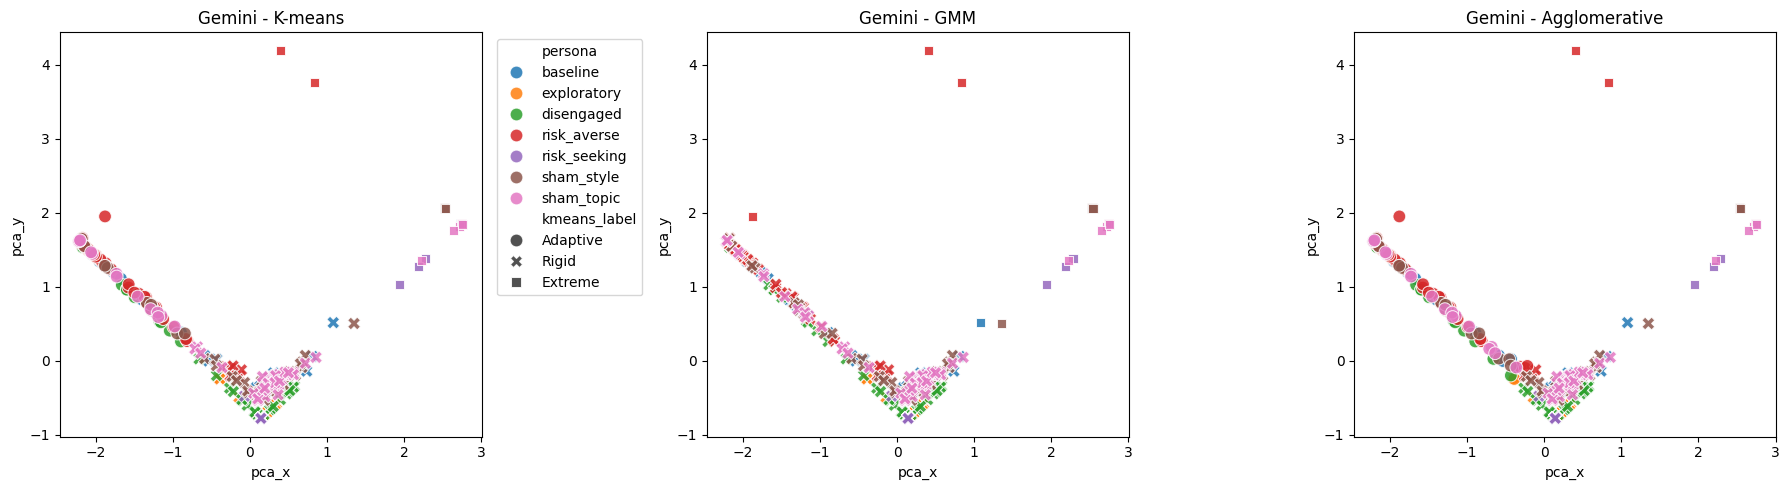

In [15]:
df_gem = df[df["dataset"] == "Gemini"].copy()
plot_three_methods(df_gem, "Gemini")

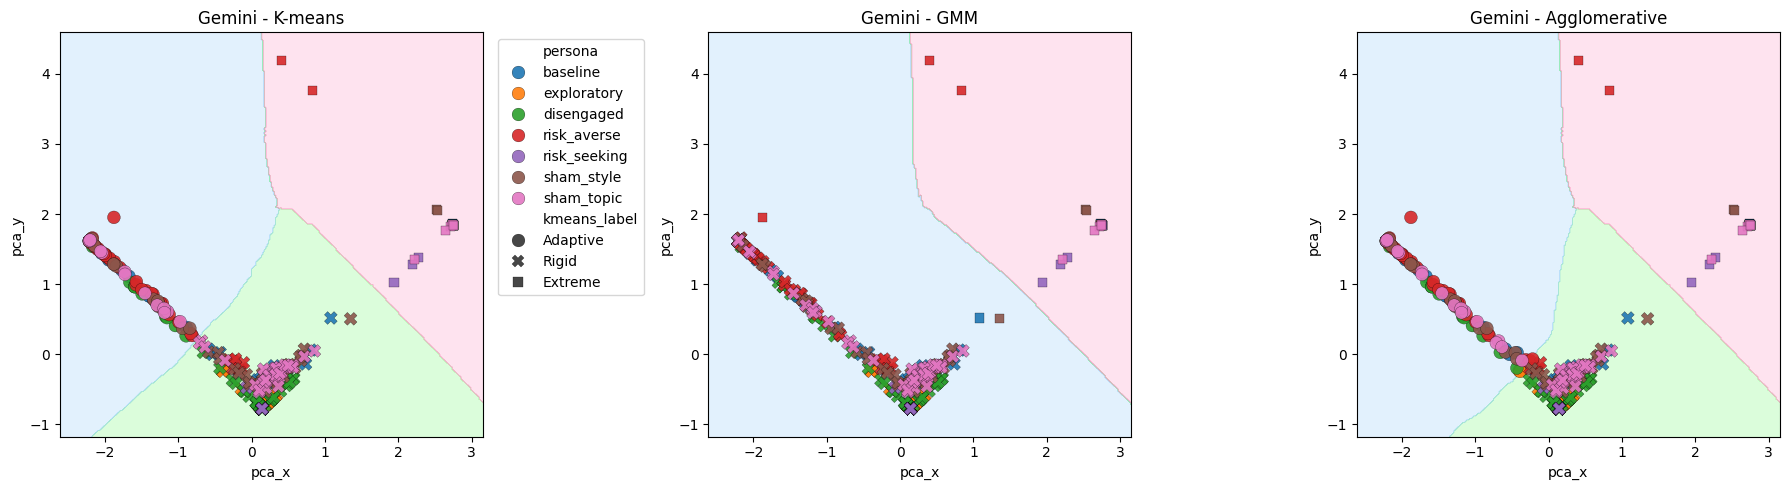

In [16]:
plot_three_methods_with_background(df_gem, "Gemini")

- Consistent clustering across methods → stable structure  
- V-shaped PCA pattern indicates a continuous behavioural spectrum  
- Majority of points fall in the Rigid cluster  
- Extreme behaviours appear as outliers  
- Personas overlap heavily → no clear separation  
- Slightly more outliers than DeepSeek → higher variability

### Deepseek Method Comparison

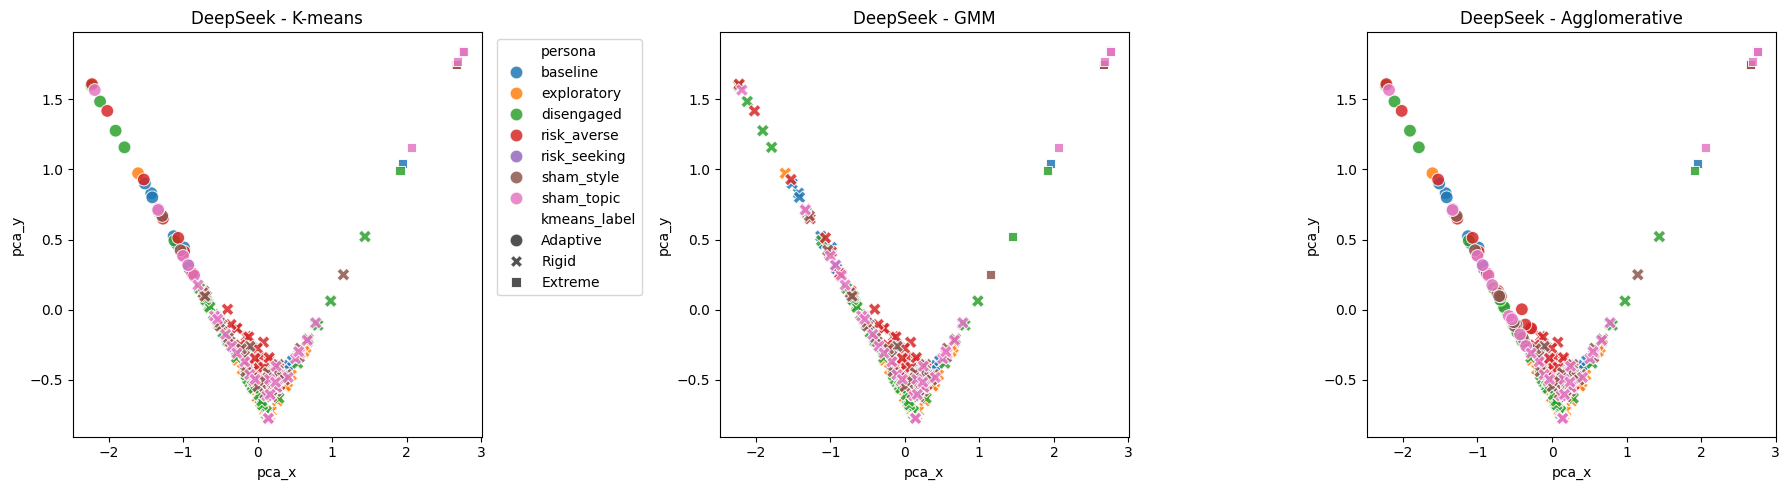

In [17]:
df_deep = df[df["dataset"] == "DeepSeek"].copy()
plot_three_methods(df_deep, "DeepSeek")

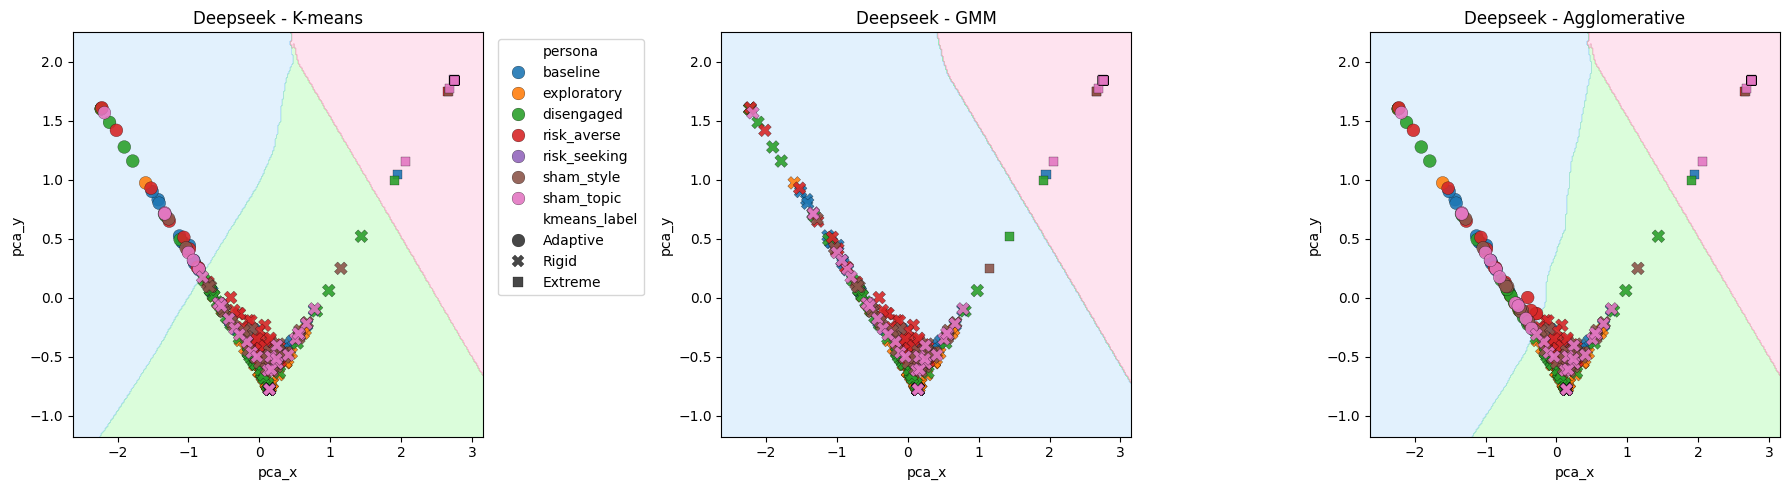

In [18]:
plot_three_methods_with_background(df_deep, "Deepseek")

- Clustering structure is consistent across K-means, GMM, and Agglomerative → results are stable
- Clear V-shaped distribution in PCA space indicates a continuous behavioural spectrum
- Most points fall in the central Rigid cluster
- Personas overlap heavily → no distinct persona-specific clusters
- Overall, behaviour varies continuously rather than forming clear discrete groups

### Combined Method Comparison

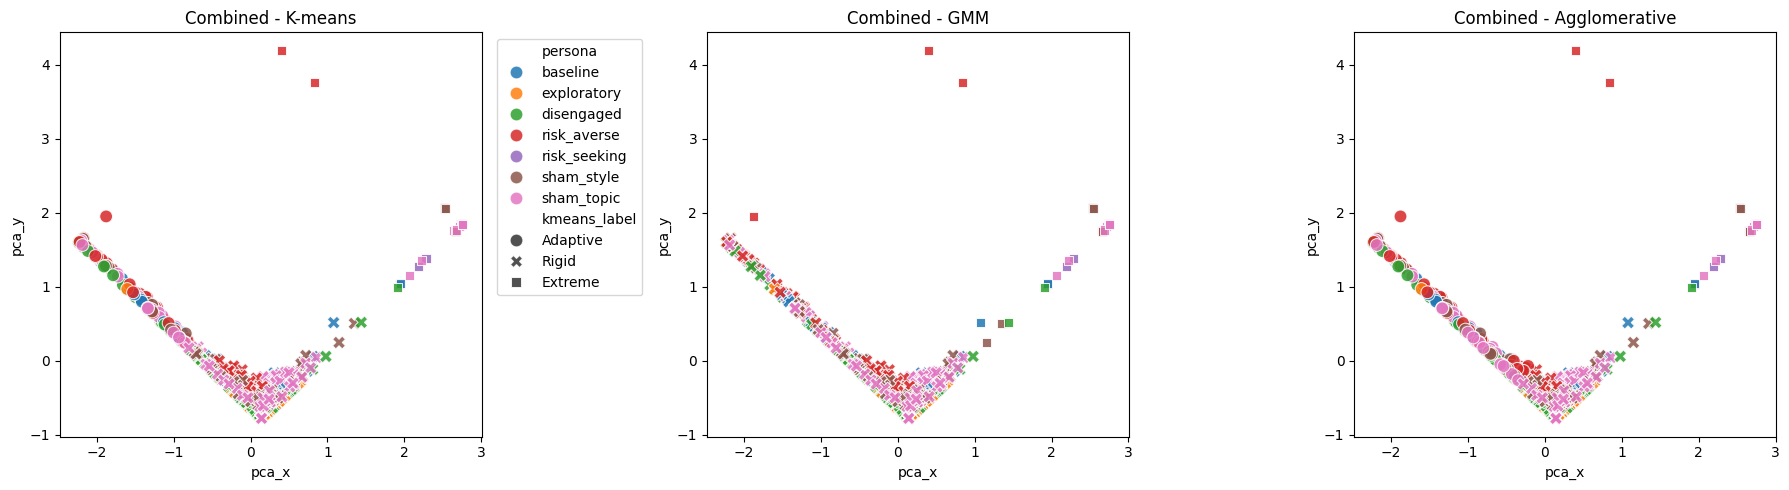

In [19]:
plot_three_methods(df, "Combined")

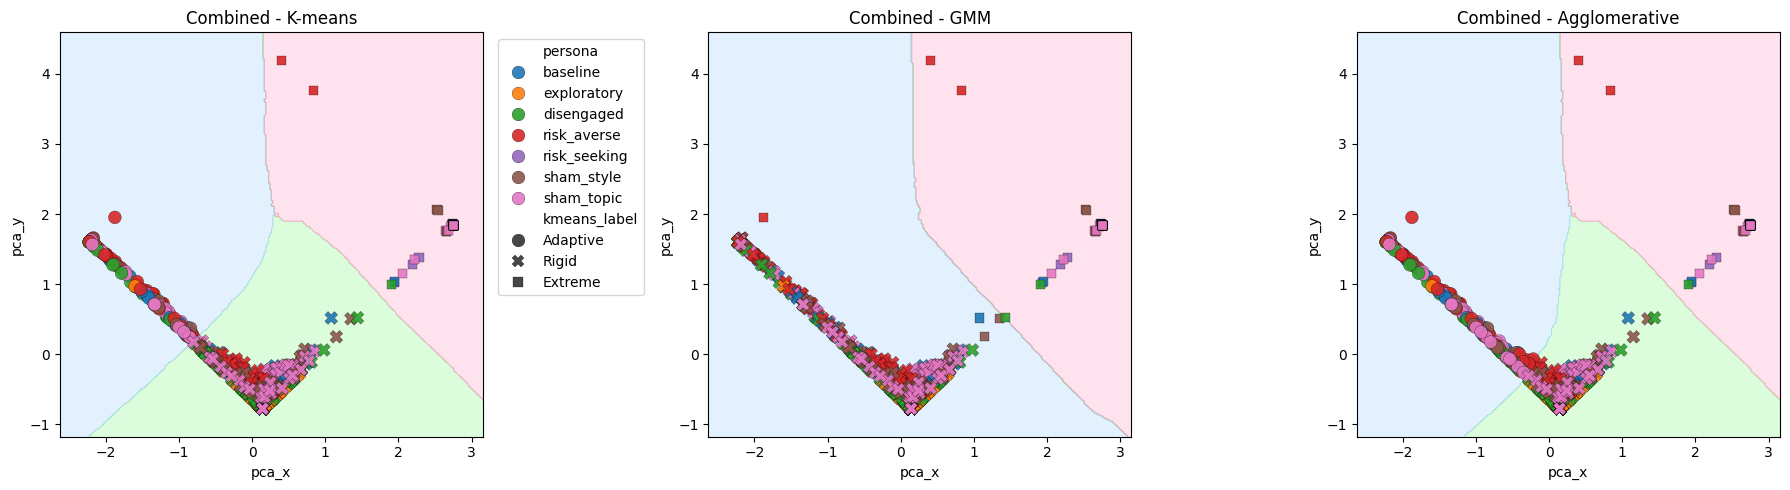

In [20]:
plot_three_methods_with_background(df, "Combined")

- Consistent clustering across all methods → strong stability  
- Clear V-shaped PCA structure → shared behavioural spectrum across datasets  
- DeepSeek and Gemini follow the same overall pattern  
- Majority of points lie in the Rigid cluster  
- Extreme behaviours appear as outliers at the edges  
- Personas overlap heavily → no clear separation across models  
- Combined data reinforces that behaviour is continuous, not discrete

In [21]:
# Model comparison
dataset_cluster_pct = pd.crosstab(df["dataset"], df["kmeans_label"], normalize="index") * 100
display(dataset_cluster_pct.round(2))

kmeans_label,Adaptive,Extreme,Rigid
dataset,,,
DeepSeek,11.14,10.29,78.57
Gemini,26.57,7.14,66.29


In [22]:
# Persona evaluation
persona_cluster_pct = pd.crosstab(df["persona"], df["kmeans_label"], normalize="index") * 100
display(persona_cluster_pct.round(2))

kmeans_label,Adaptive,Extreme,Rigid
persona,,,
baseline,30.0,11.0,59.0
disengaged,16.0,1.0,83.0
exploratory,3.0,0.0,97.0
risk_averse,48.0,5.0,47.0
risk_seeking,0.0,11.0,89.0
sham_style,16.0,10.0,74.0
sham_topic,19.0,23.0,58.0


- Most personas are dominated by the Rigid cluster → behaviour is generally consistent and not highly adaptive
- Exploratory and risk_seeking are almost entirely Rigid → not actually exploring much
- Risk_averse is the most balanced (≈ equal Adaptive and Rigid) → closest to flexible behaviour
- Sham_topic shows the highest Extreme behaviour → more variability/noise
- Baseline is fairly close to overall average behaviour
- Overall: personas shift proportions slightly, but do not create fundamentally different behavioural types

## Intrepretation across all graphs:


In [23]:
print("K-means counts")
print(df["kmeans_label"].value_counts())

print("\nGMM counts")
print(df["gmm_label"].value_counts())

print("\nAgglomerative counts")
print(df["agg_label"].value_counts())

K-means counts
kmeans_label
Rigid       507
Adaptive    132
Extreme      61
Name: count, dtype: int64

GMM counts
gmm_label
Rigid      634
Extreme     66
Name: count, dtype: int64

Agglomerative counts
agg_label
Rigid       448
Adaptive    191
Extreme      61
Name: count, dtype: int64


In [24]:
components = pd.DataFrame(
    pca.components_,
    columns=["alpha", "beta"],
    index=["PC1", "PC2"]
)

display(components.round(3))

,alpha,beta
PC1,-0.707,0.707
PC2,0.707,0.707


**pca_x (PC1) -> learning vs consistency trade-off**
- α − β
- increases when alpha is high and beta is low
- decreases when beta is high and alpha is low

**pca_y (PC2) -> overall behavioural strength**
- α + β
- increases when both alpha AND beta are high
- decreases when both are low


**Therefore:**
- Right arm of the V -> fast learners, less consistent choices
- Bottom of the V -> weak learners + random behaviour
- Left arm of the V -> slow learners, more consistent choices

In [25]:
df.groupby("kmeans_cluster")[["alpha", "beta"]].mean().round(3)

,alpha,beta
kmeans_cluster,,
0,0.068,4.796
1,0.035,96.820
2,0.751,1.022


In [26]:
pd.crosstab(df["dataset"], df["kmeans_cluster"], normalize="index") * 100

kmeans_cluster,0,1,2
dataset,,,
DeepSeek,78.571429,10.285714,11.142857
Gemini,66.285714,7.142857,26.571429


## Statistical Tests

### Chi-square test

- p < 0.05 → personas do affect behaviour
- p > 0.05 → personas don’t matter much

Note: K-means clustering was used for statistical analysis as it provided the most stable and well-separated clusters, supported by silhouette scores and agreement with agglomerative clustering.

In [27]:
ct = pd.crosstab(df["persona"], df["kmeans_label"])
print(ct)

kmeans_label  Adaptive  Extreme  Rigid
persona                               
baseline            30       11     59
disengaged          16        1     83
exploratory          3        0     97
risk_averse         48        5     47
risk_seeking         0       11     89
sham_style          16       10     74
sham_topic          19       23     58


In [28]:
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 154.6122996381508
p-value: 6.559792366427349e-27


In [29]:
for model in ["Gemini", "DeepSeek"]:
    print(f"\n--- {model} ---")
    
    sub = df[df["dataset"] == model]
    ct = pd.crosstab(sub["persona"], sub["kmeans_label"])
    
    chi2, p, _, _ = chi2_contingency(ct)
    
    print("p-value:", p)


--- Gemini ---
p-value: 6.646171321317201e-22

--- DeepSeek ---
p-value: 3.3450470803684804e-11


- Both Gemini and DeepSeek show statistically significant results (p ≈ 0)

- This means persona affects behaviour in both models

- Gemini (p ≈ 10⁻²²) → stronger effect
- DeepSeek (p ≈ 10⁻¹¹) → still strong, but weaker than Gemini

**Interpretation:**
Personas influence behaviour more strongly in Gemini than DeepSeek

**However:**
In both models, the effect is distributional (proportions) rather than creating new behavioural types

### Cramér’s V

Cramér’s V to see how strong the effect of personas is

- ~0.1 = weak
- ~0.3 = moderate
- 0.5+ = strong

In [30]:
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.327796912509584


- Confirms personas do influence behaviour, but not strongly
- Personas shift how often behaviours occur, but don’t create fundamentally different behavioural types
- Personas have a noticeable but not dominant influence on decision-making behaviour

### Standard Residuals

- if > +2 → persona is overrepresented in that cluster
- if < -2 → persona is underrepresented

In [31]:
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
residuals = (ct - expected_df) / np.sqrt(expected_df)

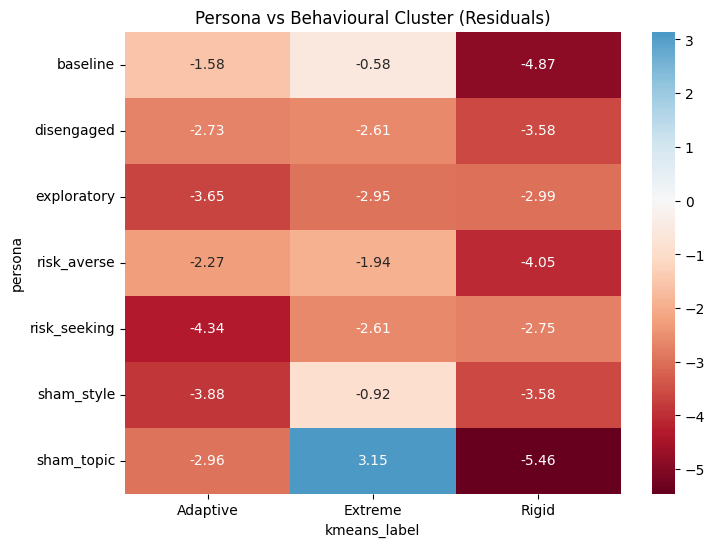

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
    residuals,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0
)

plt.title("Persona vs Behavioural Cluster (Residuals)")
plt.show()

In [33]:
df_gem = df[df["dataset"] == "Gemini"]

ct_gem = pd.crosstab(df_gem["persona"], df_gem["kmeans_label"])
chi2_g, p_g, _, exp_g = chi2_contingency(ct_gem)

res_g = (ct_gem - exp_g) / np.sqrt(exp_g)

In [34]:
df_deep = df[df["dataset"] == "DeepSeek"]

ct_d = pd.crosstab(df_deep["persona"], df_deep["kmeans_label"])
chi2_d, p_d, _, exp_d = chi2_contingency(ct_d)

res_d = (ct_d - exp_d) / np.sqrt(exp_d)

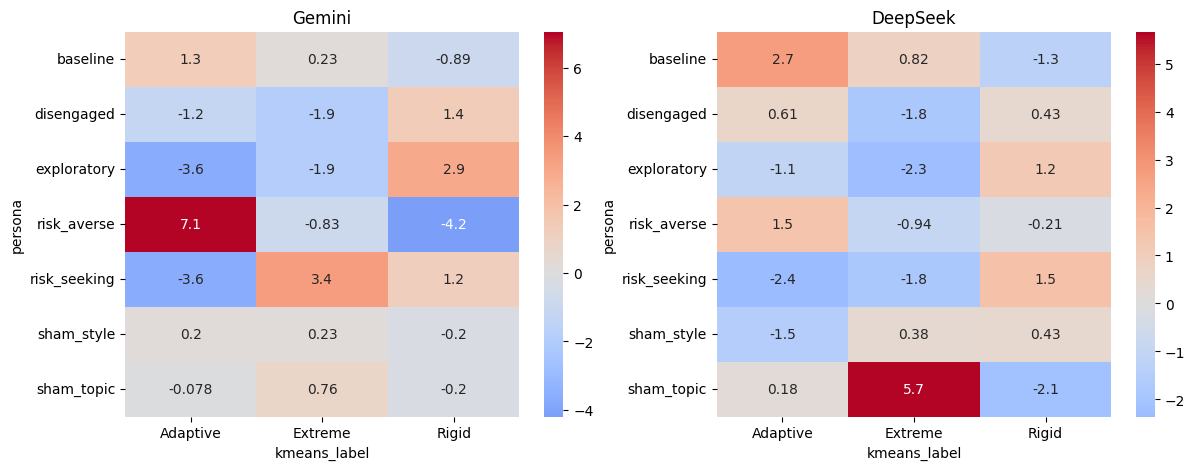

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(res_g, annot=True, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Gemini")

sns.heatmap(res_d, annot=True, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("DeepSeek")

plt.show()

# 

# Human Comparison

## RQ4: When human sessions are clustered in behavioural or RW parameter space, where do LLM personas fall relative to these human-derived clusters?

Humans are **not** used to redefine the clusters. Instead, they are projected into the AI-derived standardized α–β space and assigned to the existing K-means clusters for comparison.

In [36]:
human = pd.read_csv("../data/iowa_human/human_rw_results.csv")

print(human.shape)
print(human.columns.tolist())

# Choose only variant 2 with 100 trials
human = human[(human['experiment'] == 1) & (human["variant"] == 2)].copy()
human["dataset"] = "Human"

if "persona" not in human.columns:
    human["persona"] = "human"

print(human.shape)
print(human.columns.tolist())

human = human.dropna(subset=["alpha", "beta"]).copy()
human.head()

(511, 11)
['experiment', 'session_id', 'variant', 'n_trials', 'n_unique_choices', 'n_actions', 'action_labels', 'alpha', 'beta', 'nll', 'converged']
(222, 13)
['experiment', 'session_id', 'variant', 'n_trials', 'n_unique_choices', 'n_actions', 'action_labels', 'alpha', 'beta', 'nll', 'converged', 'dataset', 'persona']


,experiment,session_id,variant,n_trials,n_unique_choices,n_actions,action_labels,alpha,beta,nll,converged,dataset,persona
159,1,181,2,100,4,4,"K,Q,S,V",0.000100,0.000100,138.629437,True,Human,human
160,1,182,2,100,4,4,"O,P,T,U",0.999900,0.084129,135.456376,True,Human,human
161,1,183,2,100,4,4,"J,R,W,X",0.355474,0.452371,124.355013,True,Human,human
162,1,186,2,100,4,4,"F,I,W,Y",0.000100,0.000100,138.629438,True,Human,human
163,1,187,2,100,4,4,"C,K,L,P",0.000100,0.000100,138.629438,True,Human,human


In [37]:
X_human = human[["alpha", "beta"]].to_numpy()
X_human_scaled = scaler.transform(X_human)

human["kmeans_cluster"] = kmeans.predict(X_human_scaled)
human["kmeans_cluster_fixed"] = human["kmeans_cluster"].map(kmeans_map)
human["kmeans_label"] = human["kmeans_cluster_fixed"].map(label_names)

human_coords = pca.transform(X_human_scaled)
human["pca_x"] = human_coords[:, 0]
human["pca_y"] = human_coords[:, 1]

human.head()

,experiment,session_id,variant,n_trials,n_unique_choices,n_actions,action_labels,alpha,beta,nll,converged,dataset,persona,kmeans_cluster,kmeans_cluster_fixed,kmeans_label,pca_x,pca_y
159,1,181,2,100,4,4,"K,Q,S,V",0.000100,0.000100,138.629437,True,Human,human,0,1,Rigid,0.143053,-0.775698
160,1,182,2,100,4,4,"O,P,T,U",0.999900,0.084129,135.456376,True,Human,human,2,0,Adaptive,-2.229443,1.601191
161,1,183,2,100,4,4,"J,R,W,X",0.355474,0.452371,124.355013,True,Human,human,0,1,Rigid,-0.689199,0.080194
162,1,186,2,100,4,4,"F,I,W,Y",0.000100,0.000100,138.629438,True,Human,human,0,1,Rigid,0.143053,-0.775698
163,1,187,2,100,4,4,"C,K,L,P",0.000100,0.000100,138.629438,True,Human,human,0,1,Rigid,0.143053,-0.775698


In [38]:
df_all = pd.concat([df, human], ignore_index=True)

print(df_all["dataset"].value_counts())

dataset
Gemini      350
DeepSeek    350
Human       222
Name: count, dtype: int64


### Distribution Table

In [39]:
ct_dataset = pd.crosstab(df_all["dataset"], df_all["kmeans_label"])
display(ct_dataset)   # count table

ct_dataset_pct = pd.crosstab(
    df_all["dataset"],
    df_all["kmeans_label"],
    normalize="index" # for different dataset sizes
) * 100

display(ct_dataset_pct.round(2))   # percentage table

kmeans_label,Adaptive,Extreme,Rigid
dataset,,,
DeepSeek,39,36,275
Gemini,93,25,232
Human,28,48,146


kmeans_label,Adaptive,Extreme,Rigid
dataset,,,
DeepSeek,11.14,10.29,78.57
Gemini,26.57,7.14,66.29
Human,12.61,21.62,65.77


### Statistical Tests

In [40]:
chi2_ds, p_ds, dof_ds, expected_ds = chi2_contingency(ct_dataset)

print("Chi-square:", round(chi2_ds, 3))
print("p-value:", p_ds)
print("Degrees of freedom:", dof_ds)

n_ds = ct_dataset.values.sum()
cramers_v_ds = np.sqrt(chi2_ds / (n_ds * (min(ct_dataset.shape) - 1)))
print("Cramér's V:", round(cramers_v_ds, 3))

Chi-square: 57.792
p-value: 8.43693903813427e-12
Degrees of freedom: 4
Cramér's V: 0.177


very large chi-square value -> distributions very different across datasets

very low p-val -> dataset and behaviour are related

Cramér's V -> low effect

In [41]:
expected_df_ds = pd.DataFrame(expected_ds, index=ct_dataset.index, columns=ct_dataset.columns)
residuals_ds = (ct_dataset - expected_df_ds) / np.sqrt(expected_df_ds)

display(residuals_ds.round(2))

kmeans_label,Adaptive,Extreme,Rigid
dataset,,,
DeepSeek,-2.79,-0.84,1.72
Gemini,4.14,-2.55,-1.01
Human,-1.70,4.25,-0.90


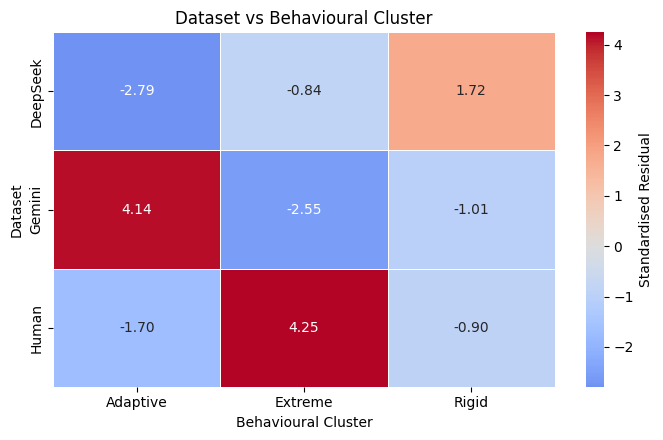

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))
sns.heatmap(
    residuals_ds,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardised Residual"}
)
plt.title("Dataset vs Behavioural Cluster")
plt.xlabel("Behavioural Cluster")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()

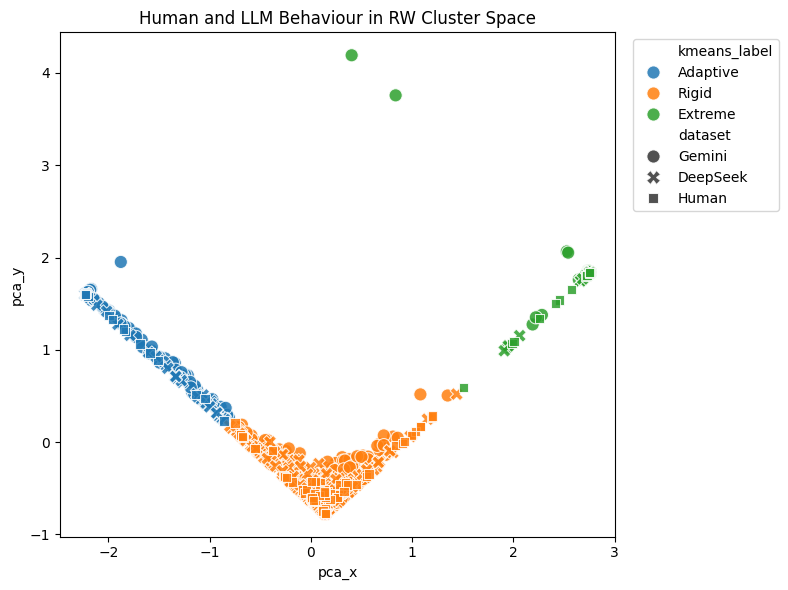

In [43]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_all,
    x="pca_x", y="pca_y",
    hue="kmeans_label",
    hue_order=["Adaptive", "Rigid", "Extreme"],
    style="dataset",
    s=90,
    alpha=0.85
)
plt.title("Human and LLM Behaviour in RW Cluster Space")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

- All datasets (Human, Gemini, DeepSeek) occupy the same overall structure
- Majority of points lie in the Rigid cluster across all groups
- No clear separation between models → differences are subtle and distributional, not structural

## Compare Humans against the AI Personas

Humans are **not** used to redefine the clusters. Instead, they are projected into the AI-derived standardized α–β space and assigned to the existing K-means clusters for comparison.

### Gemini vs Humans

In [44]:
gemini_and_human = df_all[df_all["dataset"] != "DeepSeek"]

# Create a cross-tab of just Personas (plus Human) vs Clusters
ct_persona_human = pd.crosstab(
    gemini_and_human["persona"], 
    gemini_and_human["kmeans_label"], 
    normalize="index"
) * 100

print("--- Which Gemini Persona acts most like a Human? ---")
display(ct_persona_human.round(2))

--- Which Gemini Persona acts most like a Human? ---


kmeans_label,Adaptive,Extreme,Rigid
persona,,,
baseline,36.00,8.00,56.00
disengaged,18.00,0.00,82.00
exploratory,0.00,0.00,100.00
human,12.61,21.62,65.77
risk_averse,78.00,4.00,18.00
risk_seeking,0.00,20.00,80.00
sham_style,28.00,8.00,64.00
sham_topic,26.00,10.00,64.00


* While no persona is perfect, Gemini's risk_seeking persona is close to human behaviour.
* Although, Gemini's risk_seeking persona has no ability to be 'Adaptive' (0%), it mimics the Human balance of 'Extreme' and 'Rigid' behaviors surprisingly well.

### Deepseek vs Humans

In [45]:
deepseek_and_human = df_all[df_all["dataset"] != "Gemini"] 

# Create a cross-tab of just Personas (plus Human) vs Clusters
ct_persona_human = pd.crosstab(
    deepseek_and_human["persona"], 
    deepseek_and_human["kmeans_label"], 
    normalize="index"
) * 100

print("--- Which DeepSeek Persona acts most like a Human? ---")
display(ct_persona_human.round(2))

--- Which DeepSeek Persona acts most like a Human? ---


kmeans_label,Adaptive,Extreme,Rigid
persona,,,
baseline,24.00,14.00,62.00
disengaged,14.00,2.00,84.00
exploratory,6.00,0.00,94.00
human,12.61,21.62,65.77
risk_averse,18.00,6.00,76.00
risk_seeking,0.00,2.00,98.00
sham_style,4.00,12.00,84.00
sham_topic,12.00,36.00,52.00


* The baseline model (no persona) most closely resembles human decision-making behaviour, suggesting that persona prompting generally moves the model away from natural human-like patterns.
* It's persona shifts are highly polarised (98% Rigid for risk_seeking)
* This suggests that persona prompts distort underlying learning dynamics rather than creating realistic human-like variation.